# Syndrome Lookup Tables for QEC Codes


## Part 1: Repetition Code

### Tool 1: For visualize the code

n is the number of data qubits, and the number of ancilla qubits would be m=n-1.

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

def visualize_repetition_code(n, radius=0.25, line_width=1.5):
    fig, ax = plt.subplots(figsize=(1.4 * n, 2.8))
    data_pos = [(i, 0) for i in range(n)]
    anc_pos = [(i + 0.5, 1) for i in range(n - 1)]
    # edges first so circles sit on top
    for i, (x, y) in enumerate(anc_pos):
        ax.plot([data_pos[i][0], x], [0, y], color="gray", linewidth=line_width, zorder=1)
        ax.plot([data_pos[i + 1][0], x], [0, y], color="gray", linewidth=line_width, zorder=1)
    for i, (x, y) in enumerate(data_pos):
        ax.add_patch(Circle((x, y), radius, facecolor="#1f77b4", edgecolor="black", linewidth=line_width, zorder=2))
        ax.text(x, y, f"d{i}", ha="center", va="center", color="white", fontsize=10, zorder=3)
    for i, (x, y) in enumerate(anc_pos):
        ax.add_patch(Circle((x, y), radius, facecolor="#d62728", edgecolor="black", linewidth=line_width, zorder=2))
        ax.text(x, y, f"a{i}", ha="center", va="center", color="white", fontsize=10, zorder=3)
    ax.set_xlim(-0.7, n - 0.3); ax.set_ylim(-0.6, 1.6)
    ax.set_aspect("equal"); ax.axis("off")
    plt.show()

### Tool 2: Build the lookup table ($2^m$ entries)

Enumerate X-error patterns and record down their syndrome. The lookup table has syndrome as keys, with value being the X-error patterns consistent with the syndrome.

In [5]:
from itertools import combinations

def syndrome_of(n, error):
    e = [0] * n
    for q in error:
        e[q] ^= 1
    return tuple(e[i] ^ e[i + 1] for i in range(n - 1))

def build_lookup_table(n):
    lookup = {}
    for w in range(n + 1):
        for err in combinations(range(n), w):
            s = syndrome_of(n, err)
            if s not in lookup:
                lookup[s] = err
            if len(lookup) == 2 ** (n - 1):
                return lookup
    return lookup

### Visualize the code and build the look up table

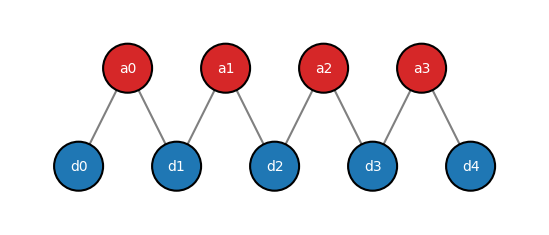

number of entries: 16 (= 2^4)
syndrome (0, 0, 0, 0) -> error ()
syndrome (0, 0, 0, 1) -> error (4,)
syndrome (0, 0, 1, 0) -> error (3, 4)
syndrome (0, 0, 1, 1) -> error (3,)
syndrome (0, 1, 0, 0) -> error (0, 1)
syndrome (0, 1, 0, 1) -> error (2, 3)
syndrome (0, 1, 1, 0) -> error (2,)
syndrome (0, 1, 1, 1) -> error (2, 4)
syndrome (1, 0, 0, 0) -> error (0,)
syndrome (1, 0, 0, 1) -> error (0, 4)
syndrome (1, 0, 1, 0) -> error (1, 2)
syndrome (1, 0, 1, 1) -> error (0, 3)
syndrome (1, 1, 0, 0) -> error (1,)
syndrome (1, 1, 0, 1) -> error (1, 4)
syndrome (1, 1, 1, 0) -> error (0, 2)
syndrome (1, 1, 1, 1) -> error (1, 3)


In [6]:

n = 5  # number of data qubits
m = n - 1  # number of ancilla qubits
visualize_repetition_code(n)

lookup = build_lookup_table(n)
print(f"number of entries: {len(lookup)} (= 2^{m})")
for s, e in sorted(lookup.items()):
    print(f"syndrome {s} -> error {e}")